<a href="https://colab.research.google.com/github/NafeesSayyed/Marketing-Mix-Modelling---Data-Science-Project/blob/main/mmm_ridge_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('mmm_processed_dataset.csv')

In [3]:
df

,week_sin,week_cos,holiday,sales_promotion,competitor_spend,instagram_spend,google_ads_spend,tv_spend,youtube_spend,newspaper_spend,influencer_spend,ott_spend,sales
0,6.631227e-01,0.748511,0,Coupons,318300.0,19352.28252,17255.978570,17296.65907,17335.03836,6825.645242,12357.741070,12471.81155,2487650
1,7.485107e-01,0.663123,0,Coupons,316400.0,19519.23078,13445.311650,17961.49303,17474.43370,7187.119487,9414.812346,15731.39330,2679131
2,8.229839e-01,0.568065,0,Coupons,280950.0,20251.35058,18254.775650,18275.03899,18046.31235,7726.462029,7031.803656,17097.82381,2748338
3,8.854560e-01,0.464723,0,Normal,311100.0,20282.68126,20665.335790,17762.93864,17575.31642,8680.294811,5132.776373,16333.91503,2683154
4,9.350162e-01,0.354605,0,Normal,256600.0,15965.33864,19764.674640,16933.77281,16334.81682,6443.062410,9561.223919,17592.96391,2584839
...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,-3.546049e-01,0.935016,0,BOGO,252250.0,19136.40416,17516.154490,15906.14190,17997.75345,6399.177780,13515.271560,18481.27306,2824619
197,-2.393157e-01,0.970942,0,Coupons,344050.0,20161.57727,13661.157220,18026.04257,17841.79001,7440.142266,15329.405610,19243.36801,2747119
198,-1.205367e-01,0.992709,0,Coupons,291550.0,21290.61638,10480.513450,18521.97568,16126.48350,7811.002283,15077.752050,19836.02606,2676494
199,6.430000e-16,1.000000,0,Normal,265650.0,20530.81473,7890.597435,17847.37146,17093.05937,8648.426478,15340.738680,18908.60835,2489367


In [4]:
X = df.drop('sales', axis = 1)
y = df['sales']

OneHot Encoding

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [3])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

Train - Test Split

In [6]:
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

Feature Scaling

In [7]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_train_scaled = sc_X.fit_transform(X_train)
X_test_scaled = sc_X.transform(X_test)

Model Training

In [8]:
from sklearn.linear_model import Ridge
regressor = Ridge(alpha = 1.0, positive=True, fit_intercept=True, solver='auto', random_state = 42)
regressor.fit(X_train_scaled, y_train)

Ridge(positive=True, random_state=42)

Model Evaluation

In [9]:
y_pred = regressor.predict(X_test_scaled)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred.reshape(len(y_pred), 1), y_test.to_numpy().reshape(len(y_test), 1)), 1))

[[2597155.71 2616604.  ]
 [2446457.56 2563774.  ]
 [2372879.34 2309863.  ]
 [2154652.69 2180514.  ]
 [2083326.92 2058161.  ]
 [1918675.96 1906430.  ]
 [2359246.8  2603953.  ]
 [2430676.29 2639995.  ]
 [2411813.96 2621384.  ]
 [2519696.41 2655601.  ]
 [2638486.29 2783100.  ]
 [2471714.09 2567493.  ]
 [2278053.6  2372824.  ]
 [2070820.35 2192540.  ]
 [2032685.2  2163927.  ]
 [2510630.62 2539843.  ]
 [2604024.27 2574071.  ]
 [2548722.21 2481141.  ]
 [2422488.32 2342117.  ]
 [2433553.84 2479184.  ]
 [2233485.94 2205311.  ]
 [2090568.01 2034506.  ]
 [1868741.57 1851341.  ]
 [1896233.18 1803401.  ]
 [1687163.88 1597048.  ]
 [1562469.96 1513716.  ]
 [1464266.4  1444750.  ]
 [1402416.72 1282763.  ]
 [1680047.85 1772506.  ]
 [1616952.74 1686361.  ]
 [1483778.32 1625483.  ]
 [1453064.09 1602643.  ]
 [2313238.76 2414361.  ]
 [2436019.07 2535608.  ]
 [2396339.21 2502857.  ]
 [2494334.54 2624574.  ]
 [2757165.06 2824619.  ]
 [2758323.26 2747119.  ]
 [2672221.16 2676494.  ]
 [2518847.03 2489367.  ]


In [10]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f"R^2: {r2 * 100:.2f}%")

R^2: 94.04%


In [11]:
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"MAPE: {mape * 100:.2f}%")

MAPE: 3.86%


In [12]:
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse}")

RMSE: 101889.20929317562


Response curve analysis to capture diminishing returns

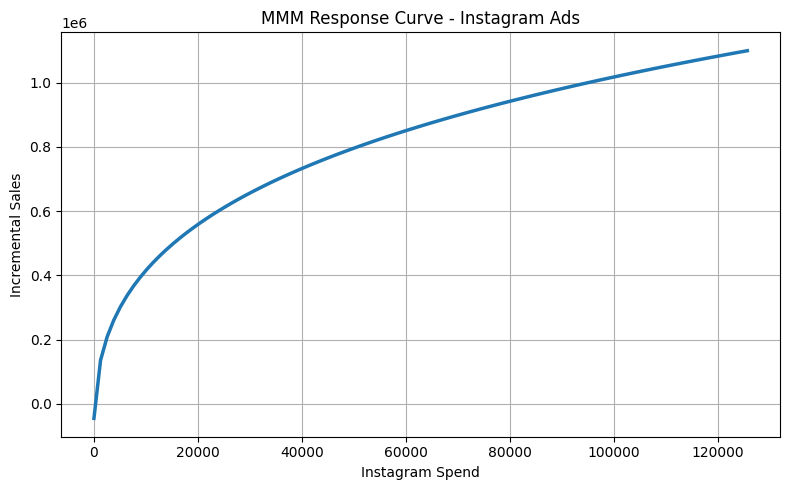

In [13]:
channel_idx = 8

max_spend = 104660

decay = 0.5

raw_spend = np.linspace(
    0,
    max_spend * 1.2,
    100
)

steady_state_adstock = raw_spend / (1 - decay)

transformed = np.log1p(
    steady_state_adstock
) ** 4

X_mean_vals = X.mean(axis=0)

X_curve = np.tile(
    X_mean_vals,
    (len(raw_spend), 1)
)

X_curve[:, channel_idx] = transformed

X_curve_scaled = sc_X.transform(X_curve)

preds = regressor.predict(X_curve_scaled)

baseline_X = X_mean_vals.copy()

baseline_X[channel_idx] = X[:, channel_idx].min()

baseline_scaled = sc_X.transform(
    baseline_X.reshape(1, -1)
)

baseline_sales = regressor.predict(
    baseline_scaled
)[0]

incremental_sales = preds - baseline_sales

plt.figure(figsize=(8,5))

plt.plot(
    raw_spend,
    incremental_sales,
    linewidth=2.5
)

plt.xlabel('Instagram Spend')
plt.ylabel('Incremental Sales')
plt.title('MMM Response Curve - Instagram Ads')

plt.grid(True)
plt.tight_layout()

plt.show()

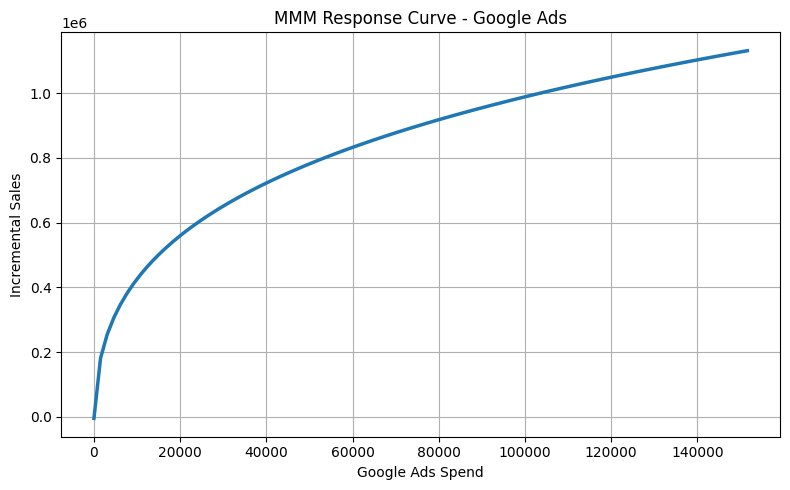

In [14]:
channel_idx = 9

max_spend = 126320

decay = 0.5

raw_spend = np.linspace(
    0,
    max_spend * 1.2,
    100
)

steady_state_adstock = raw_spend / (1 - decay)

transformed = np.log1p(
    steady_state_adstock
) ** 4

X_mean_vals = X.mean(axis=0)

X_curve = np.tile(
    X_mean_vals,
    (len(raw_spend), 1)
)

X_curve[:, channel_idx] = transformed

X_curve_scaled = sc_X.transform(X_curve)

preds = regressor.predict(X_curve_scaled)

baseline_X = X_mean_vals.copy()

baseline_X[channel_idx] = X[:, channel_idx].min()

baseline_scaled = sc_X.transform(
    baseline_X.reshape(1, -1)
)

baseline_sales = regressor.predict(
    baseline_scaled
)[0]

incremental_sales = preds - baseline_sales

plt.figure(figsize=(8,5))

plt.plot(
    raw_spend,
    incremental_sales,
    linewidth=2.5
)

plt.xlabel('Google Ads Spend')
plt.ylabel('Incremental Sales')
plt.title('MMM Response Curve - Google Ads')

plt.grid(True)
plt.tight_layout()

plt.show()

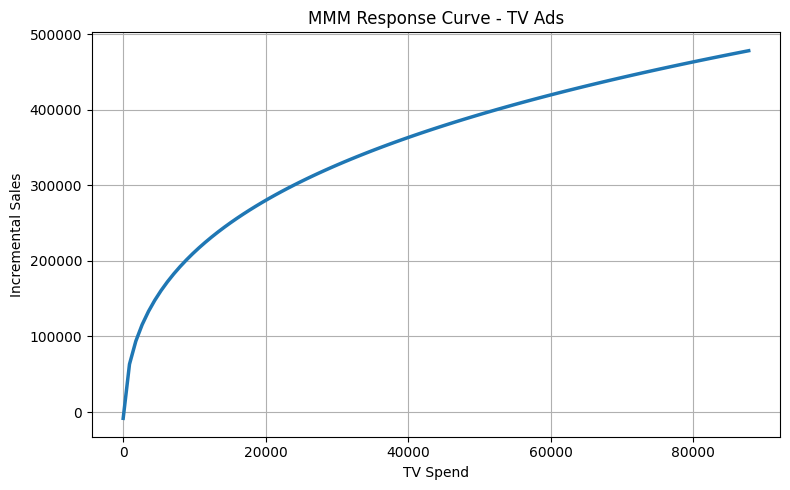

In [15]:
channel_idx = 10

max_spend = 73170

decay = 0.5

raw_spend = np.linspace(
    0,
    max_spend * 1.2,
    100
)

steady_state_adstock = raw_spend / (1 - decay)

transformed = np.log1p(
    steady_state_adstock
) ** 4

X_mean_vals = X.mean(axis=0)

X_curve = np.tile(
    X_mean_vals,
    (len(raw_spend), 1)
)

X_curve[:, channel_idx] = transformed

X_curve_scaled = sc_X.transform(X_curve)

preds = regressor.predict(X_curve_scaled)

baseline_X = X_mean_vals.copy()

baseline_X[channel_idx] = X[:, channel_idx].min()

baseline_scaled = sc_X.transform(
    baseline_X.reshape(1, -1)
)

baseline_sales = regressor.predict(
    baseline_scaled
)[0]

incremental_sales = preds - baseline_sales

plt.figure(figsize=(8,5))

plt.plot(
    raw_spend,
    incremental_sales,
    linewidth=2.5
)

plt.xlabel('TV Spend')
plt.ylabel('Incremental Sales')
plt.title('MMM Response Curve - TV Ads')

plt.grid(True)
plt.tight_layout()

plt.show()

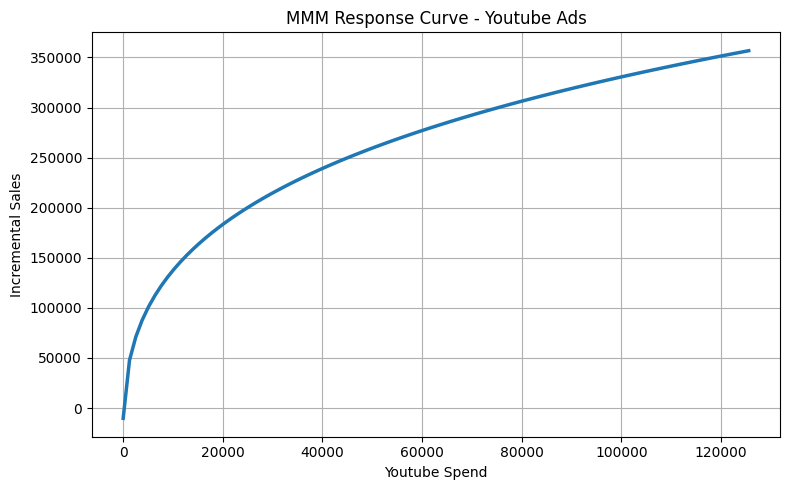

In [16]:
channel_idx = 11

max_spend = 104660

decay = 0.5

raw_spend = np.linspace(
    0,
    max_spend * 1.2,
    100
)

steady_state_adstock = raw_spend / (1 - decay)

transformed = np.log1p(
    steady_state_adstock
) ** 4

X_mean_vals = X.mean(axis=0)

X_curve = np.tile(
    X_mean_vals,
    (len(raw_spend), 1)
)

X_curve[:, channel_idx] = transformed

X_curve_scaled = sc_X.transform(X_curve)

preds = regressor.predict(X_curve_scaled)

baseline_X = X_mean_vals.copy()

baseline_X[channel_idx] = X[:, channel_idx].min()

baseline_scaled = sc_X.transform(
    baseline_X.reshape(1, -1)
)

baseline_sales = regressor.predict(
    baseline_scaled
)[0]

incremental_sales = preds - baseline_sales

plt.figure(figsize=(8,5))

plt.plot(
    raw_spend,
    incremental_sales,
    linewidth=2.5
)

plt.xlabel('Youtube Spend')
plt.ylabel('Incremental Sales')
plt.title('MMM Response Curve - Youtube Ads')

plt.grid(True)
plt.tight_layout()

plt.show()

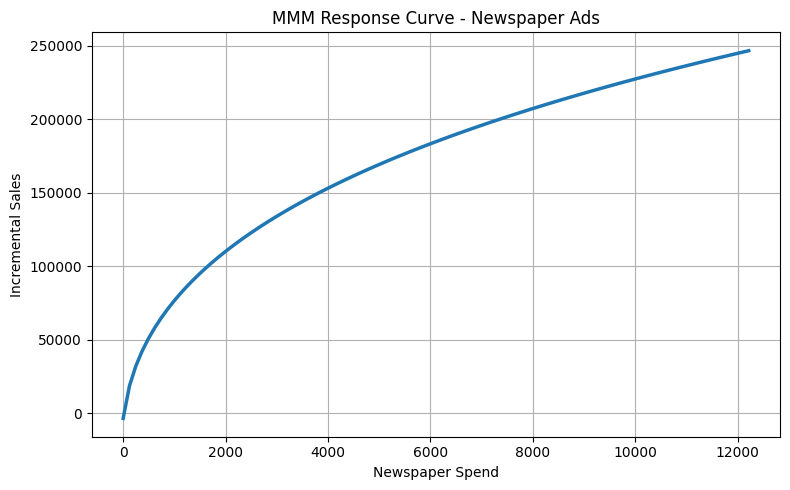

In [17]:
channel_idx = 12

max_spend = 10180

decay = 0.5

raw_spend = np.linspace(
    0,
    max_spend * 1.2,
    100
)

steady_state_adstock = raw_spend / (1 - decay)

transformed = np.log1p(
    steady_state_adstock
) ** 4

X_mean_vals = X.mean(axis=0)

X_curve = np.tile(
    X_mean_vals,
    (len(raw_spend), 1)
)

X_curve[:, channel_idx] = transformed

X_curve_scaled = sc_X.transform(X_curve)

preds = regressor.predict(X_curve_scaled)

baseline_X = X_mean_vals.copy()

baseline_X[channel_idx] = X[:, channel_idx].min()

baseline_scaled = sc_X.transform(
    baseline_X.reshape(1, -1)
)

baseline_sales = regressor.predict(
    baseline_scaled
)[0]

incremental_sales = preds - baseline_sales

plt.figure(figsize=(8,5))

plt.plot(
    raw_spend,
    incremental_sales,
    linewidth=2.5
)

plt.xlabel('Newspaper Spend')
plt.ylabel('Incremental Sales')
plt.title('MMM Response Curve - Newspaper Ads')

plt.grid(True)
plt.tight_layout()

plt.show()

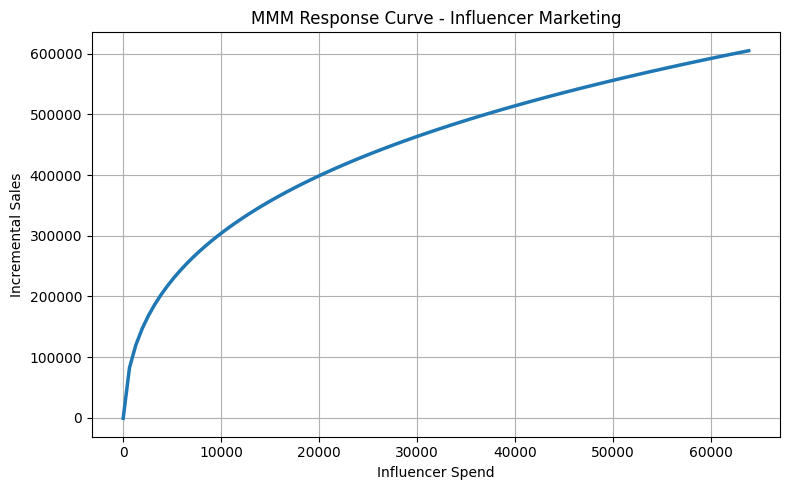

In [18]:
channel_idx = 13

max_spend = 53180

decay = 0.5

raw_spend = np.linspace(
    0,
    max_spend * 1.2,
    100
)

steady_state_adstock = raw_spend / (1 - decay)

transformed = np.log1p(
    steady_state_adstock
) ** 4

X_mean_vals = X.mean(axis=0)

X_curve = np.tile(
    X_mean_vals,
    (len(raw_spend), 1)
)

X_curve[:, channel_idx] = transformed

X_curve_scaled = sc_X.transform(X_curve)

preds = regressor.predict(X_curve_scaled)

baseline_X = X_mean_vals.copy()

baseline_X[channel_idx] = X[:, channel_idx].min()

baseline_scaled = sc_X.transform(
    baseline_X.reshape(1, -1)
)

baseline_sales = regressor.predict(
    baseline_scaled
)[0]

incremental_sales = preds - baseline_sales

plt.figure(figsize=(8,5))

plt.plot(
    raw_spend,
    incremental_sales,
    linewidth=2.5
)

plt.xlabel('Influencer Spend')
plt.ylabel('Incremental Sales')
plt.title('MMM Response Curve - Influencer Marketing')

plt.grid(True)
plt.tight_layout()

plt.show()

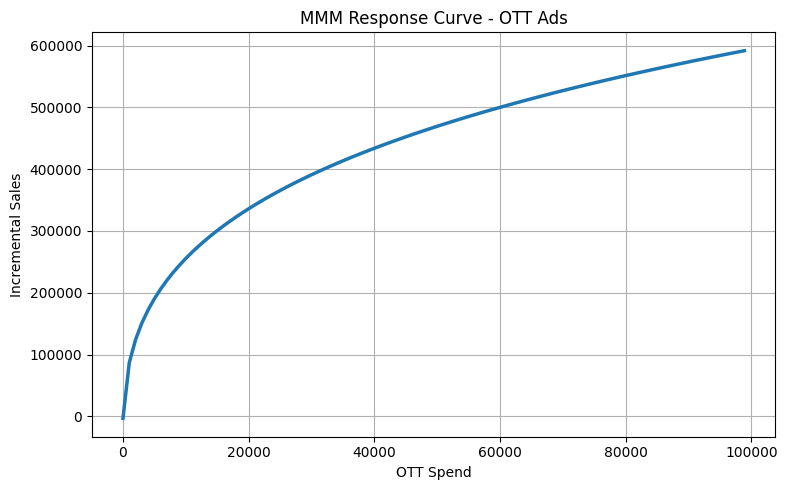

In [19]:
channel_idx = 14

max_spend = 82390

decay = 0.5

raw_spend = np.linspace(
    0,
    max_spend * 1.2,
    100
)

steady_state_adstock = raw_spend / (1 - decay)

transformed = np.log1p(
    steady_state_adstock
) ** 4

X_mean_vals = X.mean(axis=0)

X_curve = np.tile(
    X_mean_vals,
    (len(raw_spend), 1)
)

X_curve[:, channel_idx] = transformed

X_curve_scaled = sc_X.transform(X_curve)

preds = regressor.predict(X_curve_scaled)

baseline_X = X_mean_vals.copy()

baseline_X[channel_idx] = X[:, channel_idx].min()

baseline_scaled = sc_X.transform(
    baseline_X.reshape(1, -1)
)

baseline_sales = regressor.predict(
    baseline_scaled
)[0]

incremental_sales = preds - baseline_sales

plt.figure(figsize=(8,5))

plt.plot(
    raw_spend,
    incremental_sales,
    linewidth=2.5
)

plt.xlabel('OTT Spend')
plt.ylabel('Incremental Sales')
plt.title('MMM Response Curve - OTT Ads')

plt.grid(True)
plt.tight_layout()

plt.show()